# Lab 8

Link del respositorio: https://github.com/faguilarleal/lab8_vision 

#### Integrantes:
 - Francis Aguilar
 - César Lopez
 - Jose Marchena

 

## Task 1
El siguiente conjunto de preguntas evalúa su capacidad de analizar, justificar y conectar los fundamentos
matemáticos de la detección de objetos con decisiones de ingeniería reales dentro del proyecto VisorShelf.
No basta con enunciar fórmulas: se espera que usted explique el significado de cada término y argumente
su relevancia práctica en el contexto de auditoría de anaqueles

### Pregunta 1.1
El gerente de producto de VisorShelf le presenta la siguiente situación: el sistema detecta una lata de atún
en el anaquel y devuelve la caja predicha b̂ = (142, 89, 218, 165) en formato (x_min, y_min, x_max, y_max).
El radiólogo de calidad del cliente anota manualmente la caja real b* = (138, 84, 222, 170). El cliente
pregunta: "¿Qué tan buena es esa detección?"
Con esto en mente, responda las siguientes preguntas en su reporte:
1. Calcule manualmente el IoU entre las dos cajas. Muestre paso a paso el cálculo del área de
intersección, el área de unión y el valor final. Explique en términos no técnicos qué significa ese
número para el cliente de VisorShelf.

***Limites de la intersección***  
Xmin = max(142,138) = 142  
Ymin = max(89,84) = 89  
Xmax = min(218,222) = 218    
Ymax = min(165,170) = 165  

***Dimensiones***  
ancho = 218−142 = 76  
alto = 165−89 = 76  

***Area de intersección***  
∣I∣=76×76=5776

Caja predicha:

ancho = 218−142=76  
alto = 165−89=76  
área = 5776  

Caja real:  
  
ancho = 222−138=84   
alto = 170−84=86  
área = 84×86=7224  

***Area de union***  
∣U∣=5776+7224−5776=7224

IoU=∣I∣/∣U∣​= 5776 / 7224 ​≈ 0.80

R// Que el IoU sea de 0.80 indica que la detección de caja es buena, la caja predicha cubre casi por completo la ubicación real del producto. El sistema si esta identidicando bien y señalando correctamente donde esta la lata y tiene poco desviación  


2. En la fórmula IoU = |I| / |U|, identifique qué representa cada símbolo (|I|, |U|) y explique por qué
el denominador es la unión y no el área del ground truth. ¿Qué problema concreto evita esa decisión
de diseño?

R// La I representa el área de intersección, que es la parte donde ambas cajas coinciden, la U es el área de unión que es todo el espacio cubierto por ambas cajas combinadas. Si se usara unicamente el área del ground truth la caja predicha podría ser muy grande o se tendrían resultados con detecciones imprecisas que exageran el tamaño y estén desplazadas. Esto hace que la detección sea más precisa tanto en tamaño como en posición 


3. El equipo de VisorShelf está evaluando dos umbrales de IoU para decidir si una detección es válida:
θ = 0.5 y θ = 0.75. ¿Cuál recomendaría para el sistema de auditoría de anaqueles y por qué?
Considere el impacto operativo de los falsos positivos y falsos negativos en el negocio del cliente.

Para el giro de negocio recomendaría 0.75 porque es más estricto y se requiere precisión, se prioriza saber donde exactamente está el producto y qué producto es. Un falso positivo puede implicar reportar algun producto presente cuando en realidad no lo está y generar errores en el inventario. Es preferible tener falsos negativos, que implicaría perder algunas detecciones. 


### Pregunta 1.2
Durante una prueba piloto en una tienda de conveniencia, el detector de VisorShelf analiza una imagen
con 15 productos en el anaquel. El modelo genera 18 predicciones. Tras aplicar el umbral IoU = 0.5, el
equipo clasifica: 12 TP, 6 FP y 3 FN:  
Con base a esto, responda dentro de su reporte:  

4. Calcule la Precisión y el Recall para esta prueba. En las fórmulas P = TP / (TP + FP) y R = TP / (TP +
FN), explique verbalmente qué mide cada término del denominador y por qué ambas métricas son
necesarias para evaluar el sistema.  

R// Cada una de estas métricas mide un error diferente, si se tiene alta precisión y bajo recall el sistema lo que está haciendo es detectar poco pero casi sin equivocarse, en cambio cuando es al revés, que tiene alto recall y baja precisión, lo que sicede es que el sistema detecta casi todo pero se equivoca bastante. 

- **Precisión (P):** De todo lo que el sistema dijo “hay producto aquí”, ¿cuánto era correcto? TP son aciertos reales y FP son falsas alarmas
$$
P = \frac{TP}{TP + FP} = \frac{12}{12 + 6} = \frac{12}{18} \approx 0.67
$$

- **Recall (R):** De todos los productos reales, ¿cuántos logró detectar el sistema? TP son los detectados correctamente y FN los que el sistema no vio

$$
R = \frac{TP}{TP + FN} = \frac{12}{12 + 3} = \frac{12}{15} = 0.80
$$


5. El director de operaciones de la tienda le dice: "Prefiero que el sistema no se pierda ningún quiebre
de stock, aunque a veces nos avise de falsos alarmas." Traduzca esa preferencia a términos de
Precisión y Recall. ¿Qué umbral de confianza ajustaría y en qué dirección?  

R// En este caso lo que se busca es que se priorice que el sistema detecte todo sin importar que tenga falsas alarmas porque prefiere no perder stock, por lo que lo que se necesita recall alto y precisión más baja. Para lograr esto se necesita bajar el umbral del confianza del modelo para que el recall sea más alto y detecte más productos, lo que haría que tambien se eleven las falsas alarmas y por ende la precisión sea más baja. Para este caso es peor no detectar un producto faltanta que detectar algo que no es un problema. Porque el costo de perder un evento es alto. 


6. Explique qué es el mAP (Mean Average Precision) y por qué es más informativo que reportar un único
valor de Precisión o Recall. En su explicación, distinga entre mAP@0.5 (protocolo PASCAL VOC) y
mAP@0.5:0.95 (protocolo COCO), y argumente cuál protocolo sería más exigente para VisorShelf y
por qué.

R// el mAP mide el rendimiento del modelo considerante diferentes umbrales de confianza y diferentes niveles de exigencia de IoU, es el promedio del desempeño del modelo en muchos excenarios, no solo en uno. Esto lo hace más informativo, ya que refleja de manera más completa cómo se comporta el modelo en diferentes escenarios operativos y cómo equilibra la detección correcta frente a los errores. En particular, mAP@0.5 (usado en PASCAL VOC) evalúa el modelo con un único umbral de IoU de 0.5, siendo más permisivo, mientras que mAP@0.5:0.95 (usado en COCO) promedia el rendimiento en múltiples umbrales de IoU desde 0.5 hasta 0.95, lo que lo vuelve considerablemente más exigente. Para VisorShelf, esto último es más adecuado porque no solo mide si el sistema detecta los productos, sino también qué tan precisa es la localización de las cajas, algo clave en entornos donde los productos están muy juntos en el anaquel.

### Pregunta 1.3
En una imagen de anaquel con 40 productos, el modelo de VisorShelf genera 312 cajas candidatas antes
de cualquier postprocesamiento. El cliente observa el resultado intermedio y exclama: "¡El sistema está
viendo el mismo producto decenas de veces!"
Responda lo siguiente en su reporte:  

7. Explique al cliente qué es el Non-Maximum Suppression (NMS) y por qué el detector genera múltiples
cajas para el mismo objeto. Describa el algoritmo paso a paso en lenguaje no técnico.

R// es un proceso que se utiliza detecciones duplicadas y quedarse solo con la mejor caja para cada uno de los objetos. El detector genera múltiples cajas para un mismo producto porque, internamente, evalúa muchas regiones de la imagen y varias de ellas pueden coincidir sobre el mismo objeto con diferentes niveles de confianza. Como funciona es que primero ordena todas las cajas según que tan seguro esta el modelo de cada una, luego la caja con mayor confianza la toma y elimina las demás que se superponen mucho con ella. Después repute el proceso con las cajas restantes hasta que no queden sobreposiciones relevantes. Y asi se obtiene unicamente una caja detección por cada producto en lugar de muchas. 

8. El parámetro θ_NMS controla qué tan agresivo es el NMS al suprimir cajas. En un anaquel
densamente poblado donde los productos están uno junto al otro casi sin espacio, ¿qué valor de
θ_NMS recomendaría (alto o bajo) y por qué? Argumente el riesgo en cada dirección.

En un anaquel densamente poblado, se recomienda usar un θ_NMS alto, porque los productos están muy cerca entre sí y sus cajas pueden superponerse ligeramente incluso cuando corresponden a objetos distintos. Un umbral alto permite conservar esas detecciones cercanas sin eliminarlas erróneamente. Si el umbral fuera bajo, el sistema podría suprimir cajas de productos reales vecinos, generando falsos negativos (productos que no se detectan). Por otro lado, si el umbral es demasiado alto, existe el riesgo de mantener duplicados (falsos positivos), pero en este contexto es preferible ese riesgo antes que perder productos reales.

9. ¿En qué orden se deben aplicar el umbral de confianza τ y el NMS? Justifique la respuesta y explique
qué sucedería computacionalmente si se invierte ese orden en un sistema que procesa 30 imágenes
por minuto.

El orden correcto es aplicar primero el umbral de confianza (τ) y luego el NMS. Esto se debe a que el umbral elimina desde el inicio las cajas con baja probabilidad, reduciendo significativamente la cantidad de candidatos que el NMS debe procesar. Después, el NMS actúa sobre un conjunto más pequeño y relevante, haciendo el proceso más eficiente. Si se invierte el orden, el NMS tendría que operar sobre las 312 cajas iniciales, aumentando innecesariamente el costo computacional. En un sistema que procesa 30 imágenes por minuto, esto implicaría mayor uso de recursos, mayor latencia y posible degradación del rendimiento en tiempo real, sin aportar beneficios en la calidad final de las detecciones.

## Task 2

Las siguientes preguntas evalúan su comprensión estratégica de la evolución de los detectores de dos 
etapas y su capacidad de tomar decisiones de arquitectura justificadas dentro del contexto operativo de 
VisorShelf. Se valorará la coherencia del argumento con las restricciones reales del sistema.

### Pregunta 2.1

El CTO de VisorShelf propone usar el detector original R-CNN (2014) para la primera versión del sistema. El 
equipo de ingeniería calcula que con el dataset actual y una CPU de tienda, cada imagen tardaría 
aproximadamente 45 segundos en procesarse. Con esto responda en su reporte: 

1. Identifique el cuello de botella principal de R-CNN que causa esa latencia. Explique por qué procesar 2,000 propuestas de región de forma independiente es computacionalmente costoso, conectando su respuesta con lo que la red hace internamente en cada pasada.

R// El principal cuello de botella de R-CNN es que procesa cada propuesta de región de forma independiente pasando cada una por la red convolucional completa. Esto implica que si hay alrededor de 2000 regiones, la CNN se ejecuta miles de veces por imagen, repitiendo cálculos sobre zonas que muchas veces se solapan. Este diseño hace que el procesamiento sea extremadamente lento, especialmente en CPU, ya que no se reutiliza información entre regiones y cada pasada implica un costo computacional alto.

2. Fast R-CNN introdujo el feature map compartido y el RoI Pooling para resolver ese cuello de botella. Explique la lógica detrás de cada uno: ¿qué cómputo elimina el feature map compartido?, ¿qué problema resuelve el RoI Pooling y qué operación matemática realiza para producir un tensor de tamaño fijo a partir de regiones de tamaño variable?

R// Fast R-CNN resuelve este problema introduciendo el concepto de feature map compartido, donde la imagen completa se procesa una sola vez por la CNN y luego las regiones se proyectan sobre ese mapa de características. Esto elimina la redundancia de cómputo. Además, el RoI Pooling permite convertir regiones de tamaño variable en tensores de tamaño fijo, dividiéndolas en una grilla y aplicando pooling, lo que hace posible conectarlas a capas fully connected sin importar su tamaño original.

3. Con Fast R-CNN el tiempo de CNN bajó a 0.3 s/imagen, pero el tiempo total seguía siendo ~2.3 s. Identifique el nuevo cuello de botella y explique por qué Selective Search representa un problema arquitectónico más profundo que simplemente ser lento.

R// A pesar de estas mejoras, el nuevo cuello de botella pasa a ser Selective Search, que sigue tomando alrededor de dos segundos por imagen. Este método no forma parte de la red ni es entrenable, por lo que no puede optimizarse junto con el modelo. Esto lo convierte en un problema más profundo que solo la velocidad, ya que limita la posibilidad de tener un sistema verdaderamente eficiente y end-to-end.

### Pregunta 2.2

El equipo de VisorShelf decide usar Faster R-CNN como base del sistema. Un ingeniero junior pregunta: "¿Por qué necesitamos una Region Proposal Network si ya tenemos el feature map? ¿No podríamos simplemente hacer sliding window directamente sobre el feature map?" 

Responda en su reporte: 

1. Responda la pregunta del ingeniero junior. Explique qué hace la RPN que un sliding window clásico no puede hacer, y por qué el hecho de que la RPN opere sobre el mismo feature map del backbone es una ventaja semántica, no solo computacional.

R// La Region Proposal Network es necesaria porque un enfoque de sliding window sería demasiado costoso y poco eficiente. El sliding window evalúa muchas regiones de forma exhaustiva sin aprender cuáles son relevantes, mientras que la RPN aprende a generar propuestas de regiones que probablemente contienen objetos. Además, al trabajar sobre el mismo feature map del backbone, no solo comparte cómputo, sino que también aprovecha información semántica más rica para hacer mejores predicciones.

2. La RPN utiliza anchor boxes predefinidos (9 por posición: 3 escalas × 3 relaciones de aspecto). Explique qué son los anchors y por qué la red predice deltas (Δx, Δy, Δw, Δh) en lugar de coordenadas absolutas. En la decodificación $w = w_a · e^{Δw}$, identifique qué representa cada símbolo y explique por qué se usa la exponencial para las dimensiones.

R// Los anchors son cajas predefinidas que sirven como referencia para que la red aprenda a ajustar bounding boxes. En lugar de predecir coordenadas absolutas, la red aprende deltas respecto a estos anchors, lo que facilita el entrenamiento porque las predicciones son más estables. En la formula 

$$ w = w_a * e^{Δw}$$

$w_a$ representa el ancho del anchor y Δw el ajuste aprendido. El uso de la exponencial permite modelar cambios de escala y asegura que las dimensiones finales sean siempre positivas.

3. Faster R-CNN logra ~5 FPS con VGG16. La restricción de VisorShelf es procesar una imagen en menos de 500 ms (≥ 2 FPS). Tomando en cuenta esa restricción, ¿recomendaría Faster R-CNN para producción en el hardware de tienda? Argumente su respuesta considerando al menos dos factores distintos a la velocidad pura (p. ej., precisión en objetos pequeños y densos, facilidad de fine-tuning, ecosistema de implementación).

R// En cuanto a Faster R-CNN, aunque ofrece buena precisión, especialmente en objetos pequeños y densos como los de un anaquel, su desempeño en CPU puede ser limitado. Dado que el sistema requiere procesar imágenes en menos de 500 ms, es posible que el modelo necesite optimizaciones adicionales para cumplir con esta restricción. Aun así, su precisión y capacidad de adaptación lo hacen una opción viable si se prioriza la calidad de detección sobre la velocidad.

### Pregunta 2.3

El equipo de producto presenta dos propuestas para el detector de producción de VisorShelf

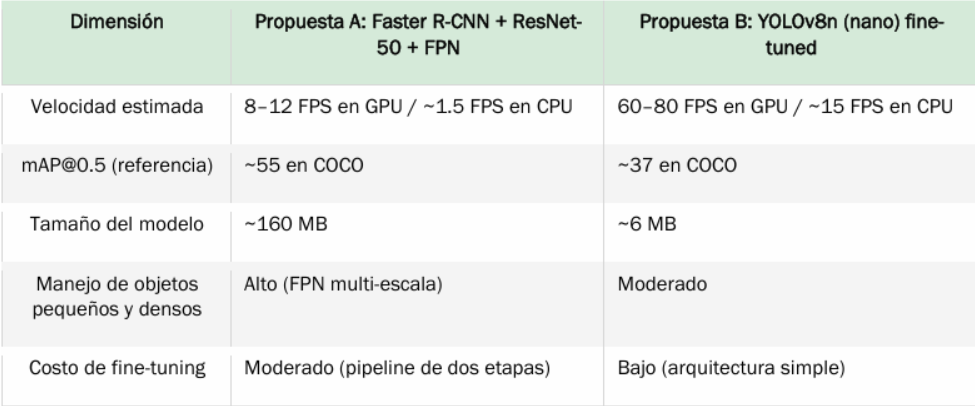

Responda en su reporte:

1. Tomando en cuenta las restricciones operativas de VisorShelf (hardware sin GPU, latencia < 500 ms, anaqueles densos), ¿cuál propuesta recomendaría y por qué? No se limite a comparar los números de la tabla; argumente la lógica de la decisión conectándola con las características técnicas de cada arquitectura.

R// Considerando que el sistema debe operar sin GPU y con una restricción de latencia estricta, la mejor opción es YOLOv8n. Aunque su precisión es menor que la de Faster R-CNN, su velocidad en CPU es significativamente mayor y cumple con el requerimiento de procesamiento en tiempo real. En un entorno operativo, es más importante garantizar que el sistema responda de forma consistente que maximizar la precisión a costa de tiempos de respuesta demasiado altos.

2. Si VisorShelf logra instalar una GPU de gama media (RTX 3060) en las tiendas flagship, ¿cambiaría su recomendación? Explique cómo ese cambio de hardware altera el trade-off entre las dos propuestas. 

R// Si se introduce una GPU como una RTX 3060, la decisión cambia, ya que Faster R-CNN pasa a ser mucho más viable en términos de velocidad. En ese escenario, su mejor desempeño en objetos pequeños y densos, especialmente usando FPN, se vuelve una ventaja importante para el contexto de anaqueles, donde los productos suelen estar muy juntos.

3. ¿Qué riesgo técnico específico introduce hacer fine-tuning de Faster R-CNN con un dataset de anaqueles sin aplicar learning rate diferenciado entre el backbone y las capas nuevas? ¿Cómo se llama ese fenómeno y cómo lo mitigaría?

R// Un riesgo importante al hacer fine-tuning de Faster R-CNN sin usar learning rate diferenciado es que el backbone pierda el conocimiento aprendido previamente, lo que se conoce como catastrophic forgetting. Esto ocurre cuando los pesos preentrenados se modifican demasiado rápido y el modelo deja de generalizar bien. Para evitarlo, se recomienda usar una tasa de aprendizaje menor en el backbone o congelarlo inicialmente y ajustar primero las capas nuevas antes de afinar todo el modelo de manera progresiva.